# Classification

## MNIST

We are going to create a **classification** model for images of handwritten digits. The objective is to train a model that is capable of recognizing which digit appears in the image.

For this, we will use [the MNIST database](https://en.wikipedia.org/wiki/MNIST_database), which contains 70,000 images of handwritten digits.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)
X, y

(70000, 784)
(70000,)


(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64),
 array(['5', '0', '4', ..., '4', '5', '6'], dtype=object))

The `fetch_openml` method from Scikit-Learn allows retrieving *datasets* from [openml](https://www.openml.org/) directly.

Keep in mind that when we want to work with images, first of all we need to understand in what format they are stored, and probably do some preprocessing of these images. In this case, the *dataset* is already preprocessed, with the images normalized to 28x28 pixels and in grayscale.

The database is divided into 60,000 training images and 10,000 test images. Each row has the image encoded in 784 columns, each of which is one of the ordered pixels (28x28 pixels), and an additional column with the label of the digit that the image represents.

We have used the `as_frame=False` parameter so that the data is retrieved in a NumPy array and not in a DataFrame, since the name of the 784 columns does not provide relevant information in this case, each one simply corresponds to one of the image pixels in order.

Each pixel has a value representing the intensity in grayscale, between 0 (white) and 255 (black).

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28) # convert the 784 pixels to a 28x28 matrix
    plt.imshow(image, cmap="binary") # display the array as an image
    plt.axis("off")

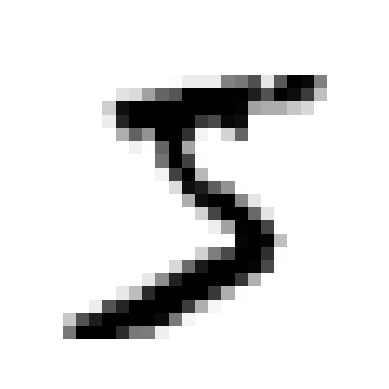

'5'

In [ ]:
index=0
some_digit = X[index]
plot_digit(some_digit)
plt.show()
y[index] # We see that it is correctly labeled

This dataset traditionally defines that the first 60000 samples are for training and the last 10000 for testing.

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

We are initially going to create a model that simply classifies whether a digit is 5 or not.

In [ ]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

We are going to use, for example, an `SGDClassifier` classifier. This classifier implements a stochastic gradient descent (an approximation to [gradient descent](https://www.youtube.com/watch?v=A6FiCDoz8_4) that aims to be less computationally expensive) over some linear *machine learning* algorithm like linear regression or support vector machines (SVM). By default it uses SVM.

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

## *Accuracy* Using *Cross-Validation*

We are going to use the `cross_val_score` function to calculate the *accuracy* (the percentage of hits) of our model using **cross-validation**.

> It is important to note that the English term "***accuracy***" is commonly translated as "***precisión***" (precision); however, in the context of statistics and *machine learning*, the correct term is "**accuracy**" or "**exactitud**", with "**precision**" (in English "***precision***") being another model evaluation metric.

[![](img/diana.png)](https://en.wikipedia.org/wiki/Accuracy_and_precision)

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

It seems that our model is very good, since it gets it right more than 95% of the time.

However, let's see what happens if we use a classifier whose only algorithm consists of always returning the most frequent label. In this case, since most labels are `False` (that is, most were not `'5'`), this model will always classify as `False`.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # Siempre devuelve false

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

We find that this absurdly simple model has a hit rate of 90%. But of course, that's because indeed, only 10% of the samples were '5' (we have 10 digits distributed uniformly). Our `DummyClassifier` is correct for all values that are not 5, which being the majority gives us a high accuracy (there are no false positives), but it doesn't get any of those that are correct.

With this example, the need for better performance metrics in classification problems than simply *accuracy* is clear. <!--TODO: especially for unbalanced datasets? asymmetric? non-uniform?-->

## Confusion Matrix

A confusion matrix is a way to visualize the performance of a classification algorithm. Each row represents a real class, while each column represents a predicted class. The elements of the main diagonal represent correct predictions, while the elements outside the main diagonal represent incorrect predictions.

We have reserved the test set for the final evaluation of the model, but the `cross_val_predict` function allows us to obtain the predictions of each instance in the training set through cross-validation.

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3) # predictions
y_train_pred

array([ True, False, False, ...,  True, False, False])

and with them we can build a confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_train_5, y_train_pred)
conf_matrix

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

where the first row indicates the negatives (not 5) and the second the positives (5). The first column indicates the predicted negatives and the second the predicted positives. Thus, the matrix counts 53892 true negatives, 687 false positives, 1891 false negatives and 3530 true positives.

![precision_recall](img/conf_matrix_5.png)

To clarify, let's imagine what the confusion matrix would be for a perfect classifier.

In [ ]:
confusion_matrix(y_train_5, y_train_5)

array([[54579,     0],
       [    0,  5421]], dtype=int64)

We observe how false positives and false negatives disappear, and only true positives (5421) and true negatives (54579) remain. The classifier would be perfect.

## Precision and *Recall*

The **precision** of a classifier is the number of correct predictions divided by the total positive predictions, that is: the percentage of positive predictions that are correct, or what is the same, the percentage of correct positive predictions.

$$ \text{Precision} = \frac{TP}{TP + FP} $$

The **recall** (also called **sensitivity** or **true positive rate**) is the number of correct predictions divided by the total instances that should have been predicted as positive, that is: the percentage of positives (values that are '5') correctly predicted.

$$ \text{Recall} = \frac{TP}{TP + FN} $$

[![](img/classfication_metrics.jpg)](https://medium.com/swlh/how-to-remember-all-these-classification-concepts-forever-761c065be33)

In [ ]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_train_5, y_train_pred)) # == 3530 / (687 + 3530)
print("Precision:", conf_matrix[1, 1] / (conf_matrix[0, 1] + conf_matrix[1, 1])) # manually from confusion matrix
print("Recall:", recall_score(y_train_5, y_train_pred)) # == 3530 / (1891 + 3530)

Precisión: 0.8370879772350012
Precisión: 0.8370879772350012
Recall: 0.6511713705958311


We see that our classifier, despite having a high *accuracy*, is only correct 83.7% of the time when it says that a digit is a '5'. And it only detects 65.1% of the '5's. This metric will only be high when both precision and *recall* are high.

There is another very popular metric which is the harmonic mean between precision and *recall*, the *F1 Score*:

$$ F1 = \frac{2}{\frac{1}{\text{Precision}} + \frac{1}{\text{Recall}}} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{TP}{TP + \frac{FN + FP}{2}} $$

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In some contexts precision is preferred, in others recall. For example, if we train a classifier to detect safe videos for children, we probably prefer a classifier that rejects many good videos (**low recall**) but keeps only the safe ones (**high precision**). On the other hand, if we train a classifier to detect thieves in surveillance images, it's probably okay if our classifier only has 30% precision (many **false alarms**) as long as it has 99% **recall**, that is: it is very **sensitive**.

In general, the higher the precision, the lower the recall, and vice versa. This is called the ***trade-off* between precision and recall**.

To display all the metrics of a classifier, we can use the `classification_report` function.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_train_5, y_train_pred))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



## Multiclass Classification

There are classifiers that can handle multiple classes directly, such as logistic regression or decision trees. Other classifiers are strictly binary, such as support vector machines. However, there are strategies to extend them to multiclass classifiers.

There are mainly two strategies to extend a binary classifier to a multiclass classifier:

- ***One-versus-the-rest* (OvR)** or *One-versus-all* (OvA): Train a binary classifier for each class. When we want to classify an instance, we obtain the decision score from each classifier and select the class whose score is the highest. In this case, we would train 10 binary classifiers, one for each digit, analogous to the one we trained to classify whether a digit is 5 or not.

- ***One-versus-one* (OvO)**: Train a binary classifier for each pair of classes. If there are N classes, we need to train N * (N - 1) / 2 classifiers: 1 to distinguish 0 and 1, another to distinguish 0 and 2, another to distinguish 1 and 2, etc. The class that wins the majority of duels is the one selected. This method needs to train many more classifiers than the previous one, but each one only needs to be trained on a part of the training set.

Scikit-learn automatically detects if we are trying to use a **binary classifier** for a **multiclass classification** task and applies one or another strategy depending on the algorithm (usually OvR, except for algorithms that scale poorly with increased samples, such as SVM)

In [ ]:
from sklearn.svm import SVC # Support Vector Classifier, using OvO

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [ ]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

It is also possible to force the use of one technique or another with Scikit-learn classifiers, using the `OneVsOneClassifier` or `OneVsRestClassifier` classes.

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [ ]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

We have used SVM with OvO by default and OvR forced. We can also use SGDClassifier again, which also applies OvR by default.

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:2000], y_train[:2000])
sgd_clf.predict([some_digit])

array(['5'], dtype='<U1')

In this case it was wrong. Let's compare the overall performance of the 3 techniques.

In [ ]:
nsamples = 10000 # try varying the number of samples

In [ ]:
print("Default SVC (SVM-OvO):",
      cross_val_score(svm_clf, X_train[:nsamples], y_train[:nsamples], cv=3, scoring="accuracy").mean())

SVC por defecto (SVM-OvO): 0.9551998991140866


In [ ]:
print("SVC with OvR:",
    cross_val_score(ovr_clf, X_train[:nsamples], y_train[:nsamples], cv=3, scoring="accuracy").mean())

SVC con OvR: 0.9538997391040844


In [ ]:
print("Default SVC optimized with SGD:",
    cross_val_score(sgd_clf, X_train[:nsamples], y_train[:nsamples], cv=3, scoring="accuracy").mean())

SVC por defecto optimizado con SGD: 0.8633997472932656


We see that OvR is much more computationally expensive as the number of samples increases. That's why SVC applies OvO by default. For its part, SGDClassifier is faster, but less efficient.

## Sources

- [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd Edition. Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/) - Chapter 3: Classification ([notebook](https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb))
- Multiclass SVM:
    - https://www.analyticsvidhya.com/blog/2021/05/multiclass-classification-using-svm/
    - https://www.baeldung.com/cs/svm-multiclass-classification